In [2]:
!pip install --quiet gdown rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 44.0 MB/s eta 0:00:00


In [3]:
import gdown
import pandas as pd
import matplotlib.pyplot as plt
from rdkit.Chem import PandasTools, Descriptors
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd

In [4]:
# 1. Extract the file ID from your share link:
#    https://drive.google.com/file/d/<FILE_ID>/view?usp=sharing
file_id = '1M9Oop7nLF387djXVqalGx_8hOyvHj51y'

# 2. Construct the download URL and fetch it
download_url = f'https://drive.google.com/uc?id={file_id}'
output_path = 'reactions_with_smiles_seq.tsv'
gdown.download(download_url, output_path, quiet=False)

# 3. Load with pandas
df = pd.read_csv(output_path, sep='\t')
df.head()

Downloading...
From: https://drive.google.com/uc?id=1M9Oop7nLF387djXVqalGx_8hOyvHj51y
To: /content/reactions_with_smiles_seq.tsv
100%|██████████| 3.22M/3.22M [00:00<00:00, 46.0MB/s]


,enzyme,sequence,cid,smiles,rate,source,reaction,acceptor
0,UGT71G1,MSMSDINKNSELIFIPAPGIGHLASALEFAKLLTNHDKNLYITVFC...,5281166,CCC=CCC1C(CCC1=O)CC(=O)O,NaN,GT-Predict extensions,0.0,Jasmonic acid
1,UGT78G1,MSTFKNEMNGNNLLHVAVLAFPFGTHAAPLLSLVKKIATEAPKVTF...,5281166,CCC=CCC1C(CCC1=O)CC(=O)O,NaN,GT-Predict extensions,0.0,Jasmonic acid
2,UGT72B10,MAETPVVTPHIAILPSPGMGHLIPLVEFSKRLIQNHHFSVTLILPT...,5281166,CCC=CCC1C(CCC1=O)CC(=O)O,NaN,GT-Predict extensions,0.0,Jasmonic acid
3,UGT74P1,MEEIPNKSHVLVLPFPVQGHINPMVQFSKRLASRGVKVTLITIDSI...,5281166,CCC=CCC1C(CCC1=O)CC(=O)O,NaN,GT-Predict extensions,0.0,Jasmonic acid
4,UGT73A10,MGQLHFFLFPMMAQGHMIPTLDMAKLIASRGVKATIITTPLNESVF...,5281166,CCC=CCC1C(CCC1=O)CC(=O)O,NaN,GT-Predict extensions,0.0,Jasmonic acid


Counts for each reaction category:
reaction
0.0    4371
1.0    1054
0.5     279
Name: count, dtype: int64


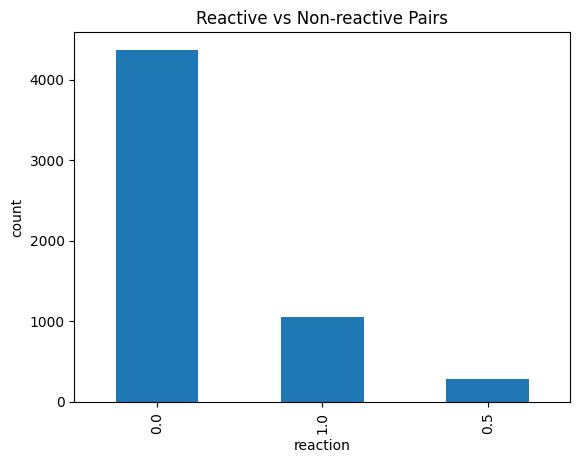

In [5]:
# Compute counts of reactive vs non-reactive
counts = df['reaction'].value_counts()
print("Counts for each reaction category:")
print(counts)

# Plot bar chart
counts.plot(kind='bar')
plt.title('Reactive vs Non-reactive Pairs')
plt.xlabel('reaction')
plt.ylabel('count')
plt.show()

In [6]:
print(f"Unique enzymes: {df['enzyme'].nunique()}")
print(f"Unique substrates: {df['cid'].nunique()}")

Unique enzymes: 155
Unique substrates: 238


In [7]:
print(df.isnull().mean())
print(f"Duplicate rows: {df.duplicated(['enzyme','cid']).sum()}")

enzyme      0.000000
sequence    0.000000
cid         0.000000
smiles      0.000000
rate        0.800666
source      0.002980
reaction    0.000000
acceptor    0.000000
dtype: float64
Duplicate rows: 34


Text(0.5, 1.0, 'Enzyme Sequence Length')

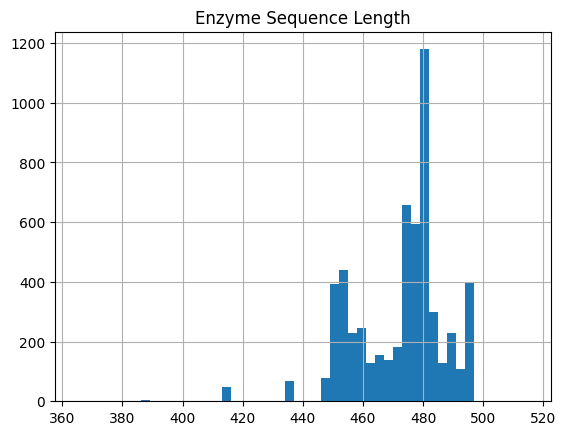

In [9]:
df['seq_len'] = df['sequence'].str.len()
df['seq_len'].hist(bins=50)
plt.title('Enzyme Sequence Length')

Text(0.5, 1.0, 'Molecular Weight')

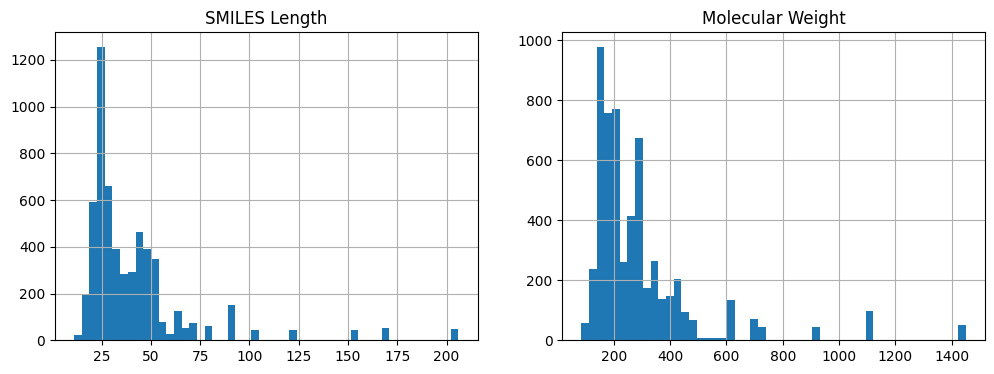

In [9]:
PandasTools.AddMoleculeColumnToFrame(df,'smiles','Mol')
df['smi_len'] = df['smiles'].str.len()
df['MolWt'] = df['Mol'].apply(Descriptors.MolWt)

fig, axes = plt.subplots(1,2, figsize=(12,4))
df['smi_len'].hist(bins=50, ax=axes[0]); axes[0].set_title('SMILES Length')
df['MolWt'].hist(bins=50, ax=axes[1]); axes[1].set_title('Molecular Weight')

In [13]:
# @title Enzyme Substrate Reactivity
# Pivot to enzyme × substrate (acceptor) matrix
mat = df.pivot_table(index='enzyme', columns='acceptor', values='reaction', fill_value=0)

# 1) Sort enzymes by total reactivity (row sum)
row_sums        = mat.sum(axis=1)
sorted_enzymes  = row_sums.sort_values(ascending=False).index
mat_sorted      = mat.loc[sorted_enzymes]

# 2) Extract labels and hover data
enzymes    = mat_sorted.index.tolist()
substrates = mat_sorted.columns.tolist()
data       = mat_sorted.values

E = np.array(enzymes)[:, None]
S = np.array(substrates)[None, :]
customdata = np.stack((np.broadcast_to(E, data.shape),
                       np.broadcast_to(S, data.shape)), axis=-1)

# 3) Plot heatmap (bottom-left origin)
fig = px.imshow(
    data,
    origin="lower",
    x=list(range(data.shape[1])),
    y=list(range(data.shape[0])),
    labels=dict(x="Substrate index", y="Enzyme index"),
    color_continuous_scale=["white", "navy"],
    zmin=0, zmax=1,
    aspect="auto"
)

# 4) Add enzyme/substrate labels in hover and hide color bar
fig.data[0].customdata = customdata
fig.data[0].hovertemplate = (
    "Enzyme: %{customdata[0]}<br>"
    "Substrate: %{customdata[1]}<br>"
    "Reaction: %{z}<extra></extra>"
)
fig.update_coloraxes(showscale=False)

# 5) Manually add binary legend (0/1)
fig.add_traces([
    go.Scatter(
        x=[None], y=[None], mode="markers",
        marker=dict(size=10, color="white",
                    line=dict(width=1, color="black")),
        showlegend=True, name="Non‑reactive (0)"
    ),
    go.Scatter(
        x=[None], y=[None], mode="markers",
        marker=dict(size=10, color="navy"),
        showlegend=True, name="Reactive (1)"
    )
])

# 6) Final layout and axis styling
fig.update_layout(
    title=dict(text="Enzyme‑Substrate Reactivity", x=0.5),
    margin=dict(l=80, r=20, t=80, b=80),
    legend=dict(orientation="h", yanchor="bottom", y=1.02,
                xanchor="right", x=1),
    plot_bgcolor="white"
)
fig.update_xaxes(
    title="Substrate index",
    ticks="outside", ticklen=5,
    showline=True, linecolor="black", mirror=True
)
fig.update_yaxes(
    title="Enzyme index",
    ticks="outside", ticklen=5,
    showline=True, linecolor="black", mirror=True
)

fig.show()
